## Introduction
The Iris dataset is a classic dataset in machine learning, consisting of measurements of iris flowers from three different species.
In this notebook, we will:
- Load and explore the dataset
- Apply Principal Component Analysis (PCA) for visualization
- Train a Decision Tree Classifier
- Evaluate and visualize the model’s performance



In [18]:
#step 1: data loading
from sklearn.datasets import load_iris
data = load_iris

In [3]:
#step 2: importing libraries
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.datasets import load_iris
from sklearn.decomposition import PCA
from sklearn.tree import DecisionTreeClassifier, plot_tree
from sklearn.model_selection import train_test_split
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

## Exploring the Dataset
Let's take a quick look at the structure of our dataset, its features, and class distribution.

In [7]:
data = load_iris()
df = pd.DataFrame(data.data, columns=data.feature_names)
df['target'] = data.target
df.head()

,sepal length (cm),sepal width (cm),petal length (cm),petal width (cm),target
0,5.1,3.5,1.4,0.2,0
1,4.9,3.0,1.4,0.2,0
2,4.7,3.2,1.3,0.2,0
3,4.6,3.1,1.5,0.2,0
4,5.0,3.6,1.4,0.2,0


In [9]:
print(df.shape)
print(df['target'].value_counts())

(150, 5)
target
0    50
1    50
2    50
Name: count, dtype: int64


## Applying PCA for Dimensionality Reduction
PCA helps us visualize high-dimensional data in two dimensions.
Although Decision Trees don’t require PCA, we use it here to understand feature distribution better.

In [10]:
x = df.drop('target', axis = 1)
y = df['target']
x_train, x_test, y_train, y_test = train_test_split(x, y, test_size=0.2, random_state = 28)

In [11]:
pca = PCA(n_components=2)
x_train_pca = pca.fit_transform(x_train)
x_test_pca = pca.transform(x_test)

In [12]:
print(pca.explained_variance_ratio_)

[0.93126064 0.04829018]


## Building and Training the Decision Tree Classifier
We initialize and train a Decision Tree model on the training dataset.


## Visualizing PCA Projection (2D)
We plot the two PCA components to see how well the different species are separated in reduced dimensions.

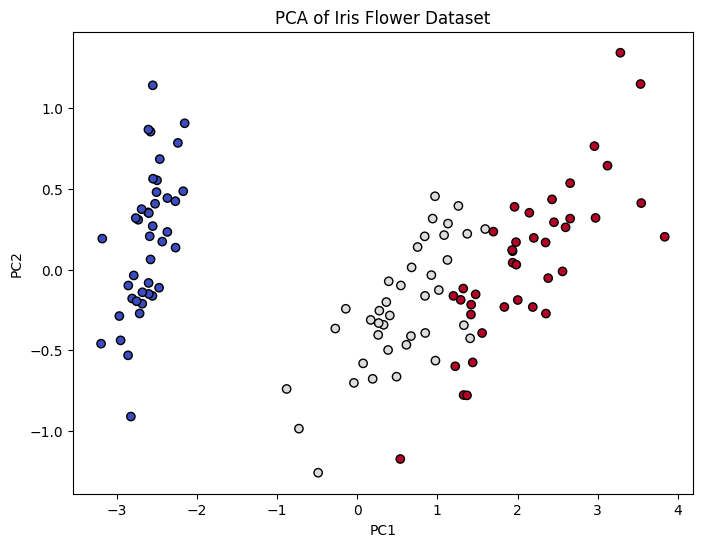

In [13]:
plt.figure(figsize=(8,6))
plt.scatter(x_train_pca[:,0], x_train_pca[:,1], c=y_train, cmap='coolwarm', edgecolor='k')
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of Iris Flower Dataset')
plt.show()

## Model Evaluation
We test the trained model on the test set and measure its accuracy, confusion matrix, and classification report.

In [14]:
model = DecisionTreeClassifier(criterion='gini', max_depth=4, random_state=28)
model.fit(x_train_pca, y_train)

DecisionTreeClassifier(max_depth=4, random_state=28)

In [15]:
y_pred = model.predict(x_test_pca)
print("Accuracy:", accuracy_score(y_test, y_pred))
print(confusion_matrix(y_test, y_pred))
print(classification_report(y_test, y_pred))

Accuracy: 0.9666666666666667
[[ 9  0  0]
 [ 0 10  1]
 [ 0  0 10]]
              precision    recall  f1-score   support

           0       1.00      1.00      1.00         9
           1       1.00      0.91      0.95        11
           2       0.91      1.00      0.95        10

    accuracy                           0.97        30
   macro avg       0.97      0.97      0.97        30
weighted avg       0.97      0.97      0.97        30



## Visualizing the Decision Tree
Let's visualize the structure of our trained Decision Tree to understand its decision-making process.

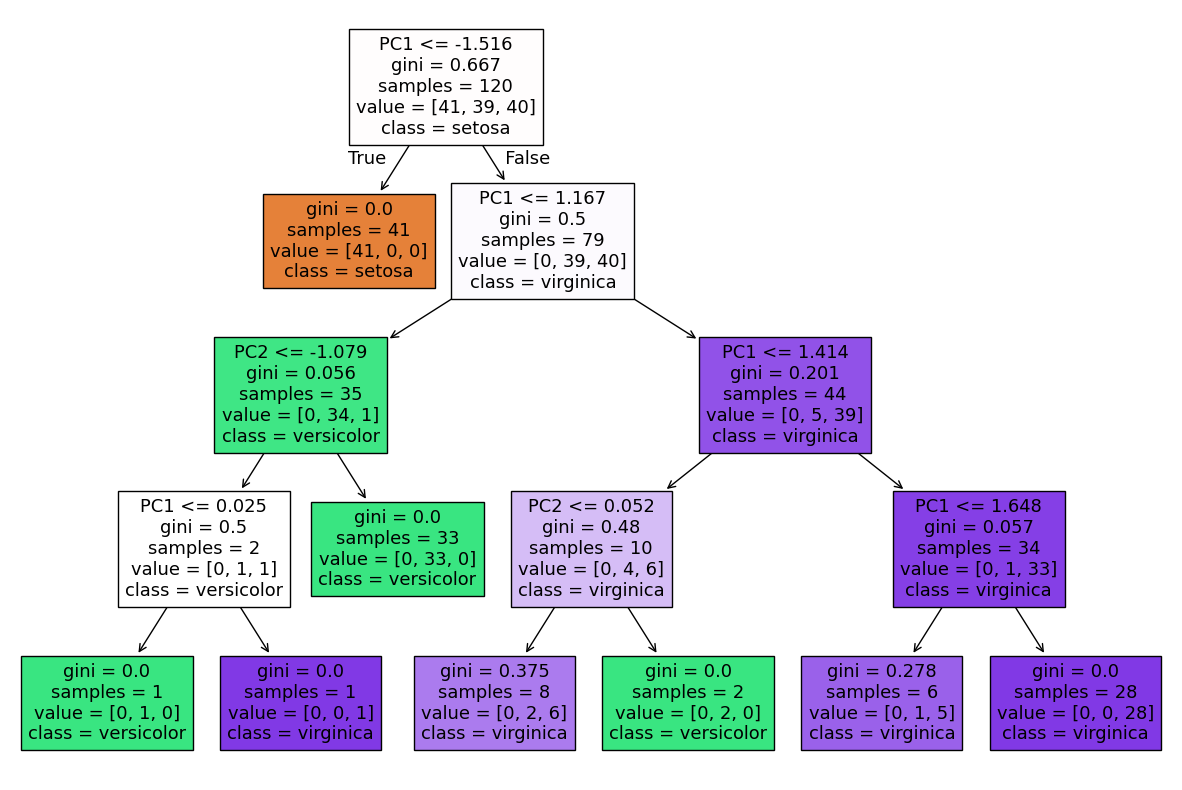

In [16]:
plt.figure(figsize=(15,10))
plot_tree(model, filled=True, feature_names=['PC1','PC2'], class_names=data.target_names)
plt.show()

## Conclusion
- The Decision Tree model successfully classified the Iris species with high accuracy.
- PCA helped visualize class separation in two dimensions.
- In future, we can experiment with other models (e.g., Random Forest, KNN) and hyperparameter tuning for improved performance.